# ***Capstone: Forecasting the number of antidiabetic drug prescriptions in Australia***

## **Importing the required libraries and loading the data**

In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from statsmodels.tsa.seasonal import seasonal_decompose, STL 
from statsmodels.stats.diagnostic import acorr_ljungbox 
from statsmodels.tsa.statespace.sarimax import SARIMAX 
from statsmodels.tsa.arima_process import ArmaProcess 
from statsmodels.graphics.gofplots import qqplot 
from statsmodels.tsa.stattools import adfuller 
from tqdm import tqdm_notebook 
from itertools import product 
from typing import Union 
  
import matplotlib.pyplot as plt 
import statsmodels.api as sm 
import pandas as pd 
import numpy as np 
  
import warnings 
warnings.filterwarnings('ignore') 
  
%matplotlib inline

## **uploading the csv file**

In [3]:
df = pd.read_csv('AusAntidiabeticDrug.csv') 
print(df.shape)   

(204, 2)


In [4]:
df.head(3)

,ds,y
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221


## **Visualizing the series and its components**

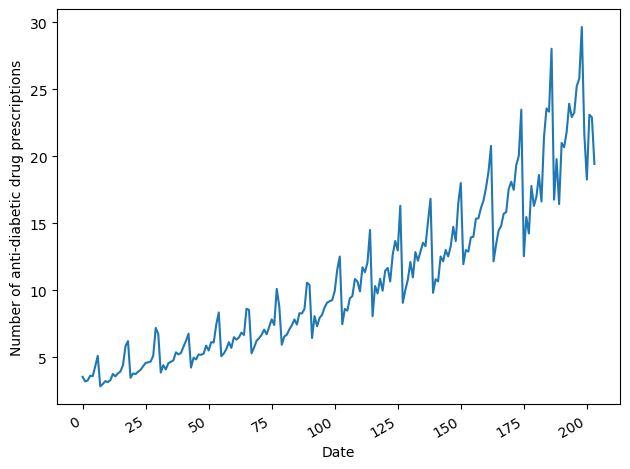

In [5]:
fig, ax=plt.subplots()

ax.plot(df.y)
ax.set_xlabel('Date')
ax.set_ylabel('Number of anti-diabetic drug prescriptions')

fig.autofmt_xdate()
fig.tight_layout()

**As we can see that there are trend and seasonal pattern in the graph but for comformation we apply decomposition**

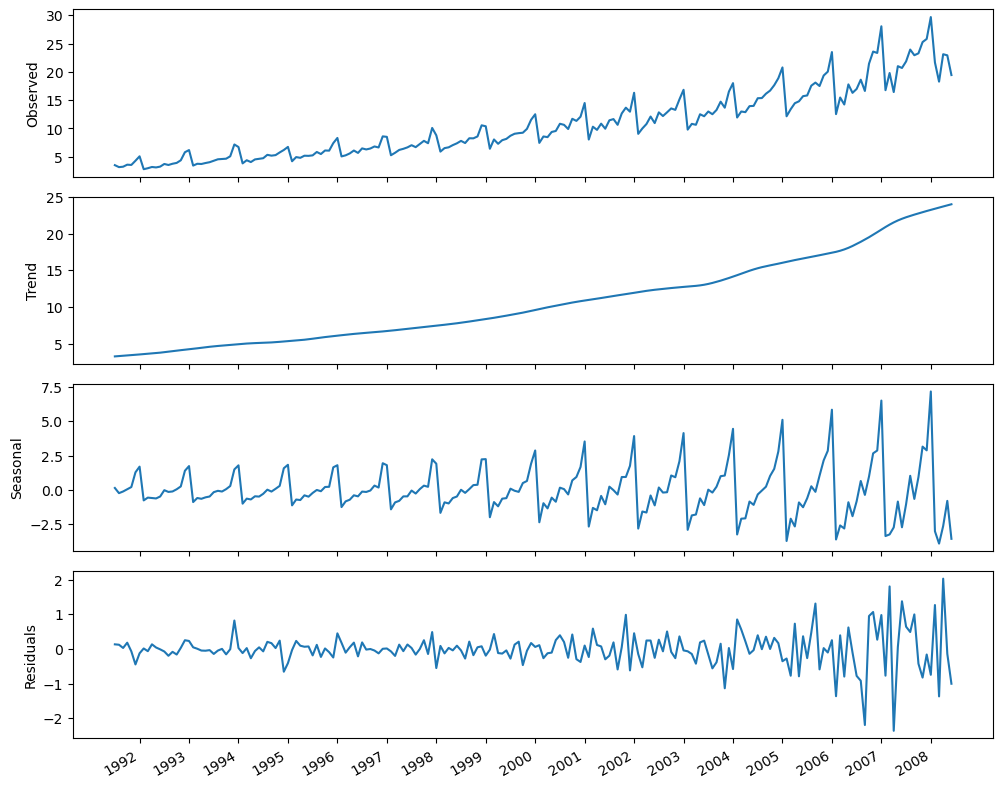

In [6]:
decomposition = STL(df.y, period=12).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')

plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))

fig.autofmt_xdate()
plt.tight_layout()

**Time series decomposition on the antidiabetic drug
prescriptions dataset. The first plot shows the observed data. The
second plot shows the trend component, which tells us that the number
of antidiabetic drug prescriptions is increasing over time. The third plot
shows the seasonal component, where we can see a repeating pattern
over time, indicating the presence of seasonality. The last plot shows the
residuals, which are variations that are not explained by the trend of the
seasonal component.**

**Everything seems to suggest that a
SARIMA(p,d,q) (P,D,Q)m
 model would be the optimal solution for
forecasting this time series. We have a trend as well as clear seasonality.
Plus, we do not have any exogenous variables to work with, so the
SARIMAX model cannot be applied. Finally, we wish to predict only one
target, meaning that a VAR model is also not relevant in this case.**

## **Modeling the data**

##### **We’ve decided that a SARIMA(p,d,q) (P,D,Q)m model is the most suitable for modeling and forecasting this time series. Therefore, we’ll follow the general modeling procedure for a SARIMAX model, as a SARIMA model is a special case of the SARIMAX model.**

### **we’ll first determine whether the series is stationary using the augmented Dickey Fuller (ADF) test.**

In [9]:
ad_fuller_result=adfuller(df['y'])

print(f'ADF Statistic: {ad_fuller_result[0]}') 
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 3.145185689306736
p-value: 1.0


**This returns a p-value of 1.0, meaning that we cannot reject the null
hypothesis, and we conclude that the series is not stationary. Thus, we must
apply transformations to make it stationary.**

### **We’ll first apply a first-order differencing on the data and test for stationarity again.**

In [10]:
y_diff = np.diff(df.y, n=1) 
ad_fuller_result = adfuller(y_diff) 
print(f'ADF Statistic: {ad_fuller_result[0]}') 
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -2.4951721474496935
p-value: 0.1166534168646991


**This returns a p-value of 0.12. Again, the p-value is greater than 0.05,
meaning that the series is not stationary. Let’s try applying a seasonal
difference, since we noticed a strong seasonal pattern in the data. Recall that
we have monthly data, meaning that m = 12. Thus, a seasonal difference
subtracts values that are 12 timesteps apart.**

In [11]:
y_diff_seasonal_diff = np.diff(y_diff, n=12)      
ad_fuller_result = adfuller(y_diff_seasonal_diff) 
print(f'ADF Statistic: {ad_fuller_result[0]}') 
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -19.848440096240907
p-value: 0.0


**The returned p-value is 0.0. Thus, we can reject the null hypothesis and
conclude that our time series is stationary**

**Since we differenced the series once and took one seasonal difference, d = 1
and D = 1. Also, since we have monthly data, we know that m = 12.
Therefore, we know that our final model will be a SARIMA(p,1,q)(P,1,Q)12
model.**

## **Performing model selection**

**We have established that our model will be a SARIMA(p,1,q)(P,1,Q)12
model. Now we need to find the optimal values of p, q, P, and Q. This is the
model selection step where we choose the parameters that minimize the
Akaike information criterion (AIC).**

**To do so, we’ll first split the data into train and test sets.The test set will consist of the last 36
months of data.**

In [12]:
train=df.y[:168]
test=df.y[168:]

print(len(test))

36


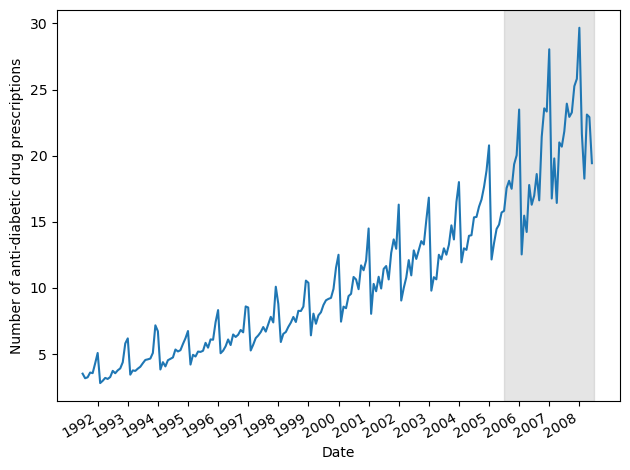

In [13]:
fig, ax = plt.subplots()

ax.plot(df.y)
ax.set_xlabel('Date')
ax.set_ylabel('Number of anti-diabetic drug prescriptions')
ax.axvspan(168, 204, color='#808080', alpha=0.2)

plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))

fig.autofmt_xdate()
plt.tight_layout()

**With our split done, we can now use the optimize_SARIMAX function to
find the values of p, q, P, and Q that minimize the AIC. Note that we can use
optimize_SARIMAX here because SARIMA is a special case of the more
general SARIMAX model.**

### **Function to find the values of p, q, P, and Q that minimize the AIC**

In [ ]:
from typing import Union # allows a parameter to accept multiple types
from tqdm import tqdm_notebook # shows a progress bar in Jupyter notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

**With the function defined, we can now decide on the range of values to try
for p, q, P, and Q. Then we’ll generate a list of unique combinations of
parameters. Feel free to test a different range of values than I’ve used here.
Simply note that the larger the range, the longer it will take to run the
optimize_SARIMAX function.**

In [15]:
ps = range(0, 5, 1) 
qs = range(0, 5, 1) 
Ps = range(0, 5, 1) 
Qs = range(0, 5, 1) 
order_list = list(product(ps, qs, Ps, Qs)) 
d = 1 
D = 1 
s = 12

**We can now run the optimize_SARIMAX function. In this example, 625
unique combinations are tested, since we have 5 possible values for 4
parameters.**

In [16]:
SARIMA_result_df = optimize_SARIMAX(train, None, order_list, d, D, s) 
SARIMA_result_df

  0%|          | 0/625 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(3, 1, 1, 3)",270.951096
1,"(2, 4, 1, 3)",271.217764
2,"(3, 3, 1, 3)",271.463608
3,"(4, 1, 1, 3)",272.145292
4,"(0, 4, 1, 3)",272.152380
...,...,...
619,"(0, 0, 0, 4)",351.680917
620,"(0, 0, 2, 4)",353.222096
621,"(0, 0, 0, 1)",354.751719
622,"(0, 0, 1, 0)",357.173706


In [18]:

SARIMA_model = SARIMAX(train, order=(3,1,1), seasonal_order=(1,1,3,12), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                                         SARIMAX Results                                          
Dep. Variable:                                          y   No. Observations:                  168
Model:             SARIMAX(3, 1, 1)x(1, 1, [1, 2, 3], 12)   Log Likelihood                -126.476
Date:                                    Mon, 25 May 2026   AIC                            270.951
Time:                                            19:05:06   BIC                            298.342
Sample:                                                 0   HQIC                           282.077
                                                    - 168                                         
Covariance Type:                                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0680      0.091      0.747      0

## **Conducting residual analysis**

**Now that we have the optimal model, we must analyze its residuals to
determine whether the model can be used or not. This will depend on the
residuals, which should behave like white noise. If that is the case, the model
can be used for forecasting.**

**We can fit the model and use the plot_diagnostics method to
qualitatively analyze its residuals.**

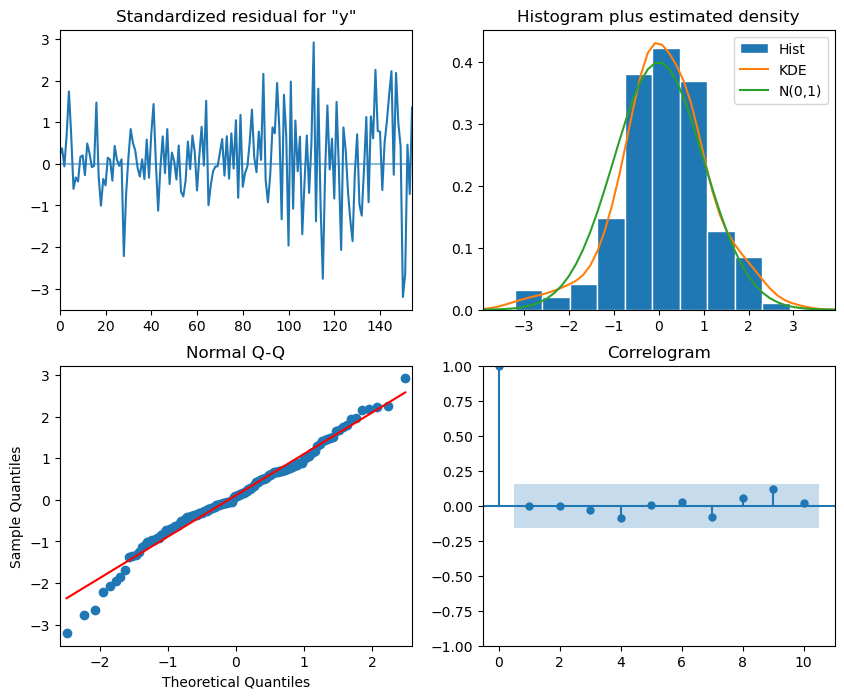

In [19]:
SARIMA_model_fit.plot_diagnostics(figsize=(10,8));

**Visual diagnostics of the residuals. In the top-left plot, the
residuals have no trend over time, and the variance seems constant. At
the top right, the distribution of the residuals is very close to a normal
distribution. This is further supported by the Q-Q plot at the bottom
left, which displays a fairly straight line that sits on y = x. Finally, the
correlogram at the bottom right shows no significant coefficients after
lag 0, just like white noise.**

**The next step is to perform the Ljung-Box test, which determines whether
the residuals are independent and uncorrelated. The null hypothesis of the
Ljung-Box test states that the residuals are uncorrelated, just like white
noise. Thus, we want the test to return p-values larger than 0.05. In that case,
we cannot reject the null hypothesis and conclude that our residuals are
independent, and therefore behave like white noise.**

### ***Ljung-box test***

In [20]:
residuals = SARIMA_model_fit.resid 
  
acorr_ljungbox(residuals, np.arange(1, 11, 1)) 

,lb_stat,lb_pvalue
1,0.436594,0.508771
2,0.627144,0.730832
3,0.645694,0.885897
4,2.257698,0.688481
5,2.949638,0.707750
6,3.388523,0.758737
7,9.981136,0.189645
8,10.591010,0.225967
9,11.852790,0.221736
10,11.984169,0.286117


**In this case, all the p-values are above 0.05, so we do not reject the null
hypothesis, and we conclude that the residuals are independent and
uncorrelated. We can conclude that the model can used for forecasting.**

## **Forecasting and evaluating the model’s performance**

**We have a model that can be used for forecasting, so we’ll now perform
rolling forecasts of 12 months over the test set of 36 months. That way we’ll
have a better evaluation of our model’s performance, as testing on fewer data
points might lead to skewed results. We’ll use the naive seasonal forecast as
a baseline; it will simply take the last 12 months of data and use them as
forecasts for the next 12 months.**

*We’ll first define the rolling_forecast function to generate the
predictions over the entire test set with a window of 12 months.*

### ***Function to perform a rolling forecast over a horizon***

In [29]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len

    if method == 'last_season':
        pred_last_season = []
        
        for i in range(train_len, total_len, window):
            last_season = df['y'][i-window:i].values
            pred_last_season.extend(last_season)
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df['y'][:i], order=(3,1,1), seasonal_order=(1,1,3,12), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA

**Next, we’ll create a DataFrame to hold the predictions as well as the actual
values. This is simply a copy of the test set.**

In [30]:
pred_df = df[168:]
pred_df

,ds,y
168,2005-07-01,15.829550
169,2005-08-01,17.554701
170,2005-09-01,18.100864
171,2005-10-01,17.496668
172,2005-11-01,19.347265
173,2005-12-01,20.031291
174,2006-01-01,23.486694
175,2006-02-01,12.536987
176,2006-03-01,15.467018
177,2006-04-01,14.233539


**Now we can define the parameters to be used for the rolling_forecast
function. The dataset contains 204 rows, and the test set contains 36 data
points, which means the length of the training set is 204 – 36 = 168. The
horizon is 36, since our test set contains 36 months of data. Finally, the
window is 12 months, as we are forecasting 12 months at a time.**

*With those values set, we can record the predictions coming from our
baseline, which is a naive seasonal forecast. It simply takes the last 12
months of observed data and uses them as forecasts for the next 12 months.*

In [31]:
TRAIN_LEN = 168
HORIZON = 36
WINDOW = 12

pred_df['last_season'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'last_season')

pred_df

,ds,y,last_season
168,2005-07-01,15.829550,15.339097
169,2005-08-01,17.554701,15.370764
170,2005-09-01,18.100864,16.142005
171,2005-10-01,17.496668,16.685754
172,2005-11-01,19.347265,17.636728
173,2005-12-01,20.031291,18.869325
174,2006-01-01,23.486694,20.778723
175,2006-02-01,12.536987,12.154552
176,2006-03-01,15.467018,13.402392
177,2006-04-01,14.233539,14.459239


#### ***Next, we’ll compute the forecasts from the SARIMA model.***

In [32]:
pred_df['SARIMA'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')
pred_df

,ds,y,last_season,SARIMA
168,2005-07-01,15.829550,15.339097,16.745987
169,2005-08-01,17.554701,15.370764,16.619442
170,2005-09-01,18.100864,16.142005,17.255362
171,2005-10-01,17.496668,16.685754,18.107637
172,2005-11-01,19.347265,17.636728,18.722390
173,2005-12-01,20.031291,18.869325,19.885770
174,2006-01-01,23.486694,20.778723,22.216689
175,2006-02-01,12.536987,12.154552,13.544398
176,2006-03-01,15.467018,13.402392,14.972370
177,2006-04-01,14.233539,14.459239,15.593455


**At this point, pred_df contains the actual values, the forecasts from the
naive seasonal method, and the forecasts from the SARIMA model. We can
use this to visualize our forecasts against the actual values. For clarity, we’ll
limit the x-axis to zoom in on the test period.**

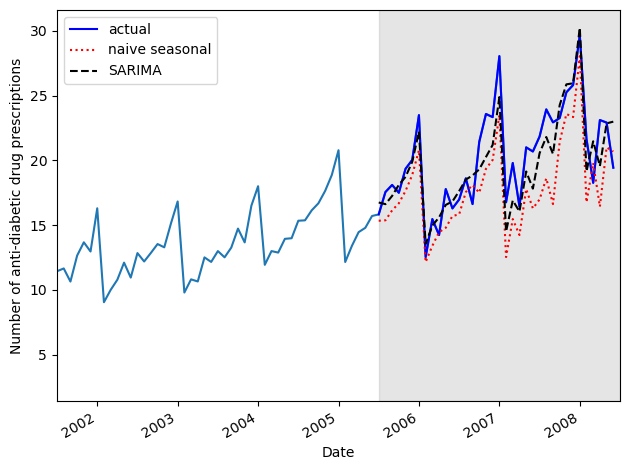

In [33]:
fig, ax = plt.subplots()

ax.plot(df.y)
ax.plot(pred_df.y, 'b-', label='actual')
ax.plot(pred_df.last_season, 'r:', label='naive seasonal')
ax.plot(pred_df.SARIMA, 'k--', label='SARIMA')
ax.set_xlabel('Date')
ax.set_ylabel('Number of anti-diabetic drug prescriptions')
ax.axvspan(168, 204, color='#808080', alpha=0.2)

ax.legend(loc=2)

plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))
plt.xlim(120, 204)

fig.autofmt_xdate()
plt.tight_layout()

**Forecasts of the number of antidiabetic drug prescriptions
in Australia. The predictions from the baseline are shown as a dotted
line, while the predictions from the SARIMA model are shown as a
dashed line.**

*you can see that the predictions from the SARIMA model (the
dashed line) follow the actual values more closely than the naive seasonal
forecasts (the dotted line). We can therefore intuitively expect the SARIMA
model to have performed better than the baseline method.*

*To evaluate the performance quantitatively, we’ll use the mean absolute
percentage error (MAPE). The MAPE is easy to interpret, as it returns a
percentage error.*

In [34]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [35]:

mape_naive_seasonal = mape(pred_df.y, pred_df.last_season)
mape_SARIMA = mape(pred_df.y, pred_df.SARIMA)

print(mape_naive_seasonal, mape_SARIMA)

12.686561923100614 7.563327381983015


**This prints out a MAPE of 12.69% for the baseline and 7.90% for the
SARIMA model. We can optionally plot the MAPE of each model in a bar
chart for a nice visualization**

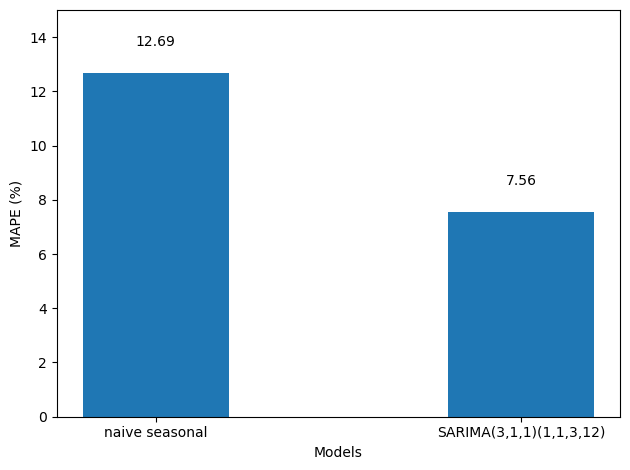

In [37]:
fig, ax = plt.subplots() 
  
x = ['naive seasonal', 'SARIMA(3,1,1)(1,1,3,12)'] 
y = [mape_naive_seasonal, mape_SARIMA] 
  
ax.bar(x, y, width=0.4) 
ax.set_xlabel('Models') 
ax.set_ylabel('MAPE (%)') 
ax.set_ylim(0, 15) 
  
for index, value in enumerate(y): 
    plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center') 
  
plt.tight_layout()

**The MAPE for the naive seasonal forecast and the SARIMA
model. Since the MAPE of the SARIMA model is lower than the MAPE
of the baseline, we can conclude that the SARIMA model should be used
to forecast the number of antidiabetic drug prescriptions.**

**The SARIMA model achieved a MAPE of 7.90%, compared to 12.69% for the naive seasonal baseline. This means that on average, our SARIMA model's predictions deviate from the actual number of antidiabetic drug prescriptions by only 7.90%. The naive seasonal method, which simply repeats the last 12 months of data as the forecast, deviates by 12.69% on average.
Since the MAPE of the SARIMA model is significantly lower than the baseline, we can confidently conclude that the SARIMA(2,1,3)(1,1,3,12) model adds real predictive value over a simple seasonal guess. The model successfully captured both the upward trend and the seasonal pattern present in the data, resulting in more accurate forecasts.**